# CPC file example

In [29]:
from __future__ import annotations
import re
from pathlib import Path
from typing import Tuple, List, Optional

import numpy as np
from PIL import Image

# OPTIONAL: enable OpenCV path (fast/headless).
try:
    import cv2
    _HAS_CV2 = True
except Exception:
    _HAS_CV2 = False

# ---------- CONFIG ----------
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}
FLOAT = r"[+-]?(?:\d+(?:\.\d+)?|\.\d+)"
PAIR_RE = re.compile(rf'^\s*"?\s*({FLOAT})\s*"?\s*,\s*"?\s*({FLOAT})\s*"?\s*$')
NUMS_RE = re.compile(rf"{FLOAT}")

# ---------- CPC parsing ----------
def _read_text(path: Path) -> str:
    for enc in ("utf-8-sig", "latin-1"):
        try:
            return path.read_text(encoding=enc, errors="strict")
        except Exception:
            pass
    return path.read_text(encoding="utf-8", errors="ignore")

def parse_cpc(path: Path) -> Tuple[float, float, List[Tuple[float, float]]]:
    """
    Returns (work_w, work_h, roi_points[4]) in CPC working coordinates.
    Assumes header on line 0, four corner pairs on lines 1.. (as in your sample).
    """
    text = _read_text(path)
    lines = [ln.strip() for ln in text.splitlines() if ln.strip() != ""]
    if not lines:
        raise ValueError(f"Empty CPC: {path}")

    nums = [float(s) for s in NUMS_RE.findall(lines[0])]
    if len(nums) < 4:
        raise ValueError(f"Unexpected CPC header format: {path}")
    work_w, work_h = float(nums[-4]), float(nums[-3])

    roi: List[Tuple[float, float]] = []
    i = 1
    while i < len(lines) and len(roi) < 4:
        m = PAIR_RE.match(lines[i])
        if m:
            roi.append((float(m.group(1)), float(m.group(2))))
        i += 1
    if len(roi) != 4:
        raise ValueError(f"Could not find 4 ROI corners in {path}")
    return work_w, work_h, roi

# ---------- helpers ----------
def _find_image_by_stem(stem: str, images_dir: Path) -> Optional[Path]:
    for ext in IMAGE_EXTS:
        p = images_dir / f"{stem}{ext}"
        if p.exists(): return p
        p2 = images_dir / f"{stem}{ext.upper()}"
        if p2.exists(): return p2
    # fallback: slow scan
    for p in images_dir.iterdir():
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS and p.stem.lower() == stem.lower():
            return p
    return None

def _scale_points_to_pixels(roi, work_w, work_h, img_w, img_h):
    sx, sy = img_w / work_w, img_h / work_h
    return [(x * sx, y * sy) for (x, y) in roi]

# ---------- Matplotlib overlay (pretty) ----------
def create_overlay_mpl(
    input_path: str | Path,
    images_dir: str | Path,
    cpcs_dir: str | Path,
    out_path: str | Path | None = None,
    show_vertices: bool = True,
):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Polygon

    input_path = Path(input_path)
    images_dir, cpcs_dir = Path(images_dir), Path(cpcs_dir)
    if input_path.suffix.lower() == ".cpc":
        stem = input_path.stem
        cpc_path = input_path
        img_path = _find_image_by_stem(stem, images_dir)
    else:
        stem = input_path.stem
        img_path = input_path
        cpc_path = cpcs_dir / f"{stem}.cpc"

    if img_path is None or not img_path.exists():
        raise FileNotFoundError(f"Image not found for stem '{stem}' in {images_dir}")
    if not cpc_path.exists():
        raise FileNotFoundError(f"CPC not found: {cpc_path}")

    work_w, work_h, roi = parse_cpc(cpc_path)

    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    roi_px = _scale_points_to_pixels(roi, work_w, work_h, w, h)

    # draw overlay
    arr = np.asarray(img)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(arr)
    poly = Polygon(np.array(roi_px, dtype=np.float32), closed=True, fill=False, linewidth=4, color="#d95f02")
    ax.add_patch(poly)
    if show_vertices:
        xs, ys = zip(*roi_px)
        ax.scatter(xs, ys, s=70, color="#1b9e77")
    ax.axis("off")
    if out_path is None:
        out_path = img_path.with_name(f"{stem}_overlay.png")
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    # plt.savefig(out_path, dpi=600, bbox_inches="tight", facecolor="auto")
    # plt.close(fig)
    return fig


# ---------- One-call convenience (choose backend) ----------
def create_quadrant_overlay(
    input_path: str | Path,
    images_dir: str | Path,
    cpcs_dir: str | Path,
    out_path: str | Path | None = None,
):
    """
    Create a single overlay image for either a .cpc file or its matching image.
    Returns the saved overlay path.
    """
    return create_overlay_mpl(input_path, images_dir, cpcs_dir, out_path=out_path)

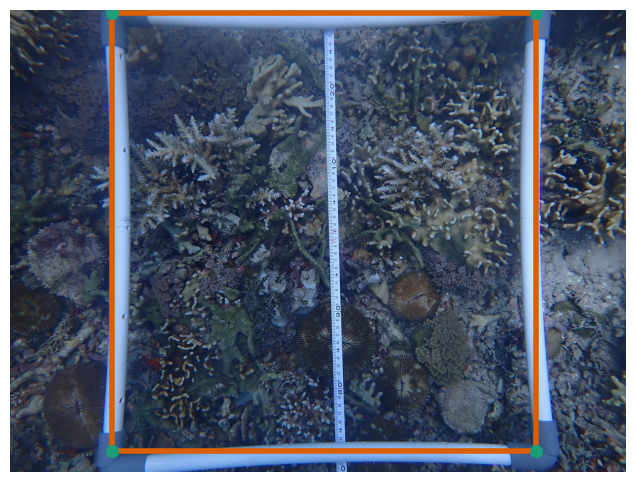

In [30]:
BASE = Path("./automated_underwater_area_estimation/data_preprocessed/IBF/")
IMAGES_DIR = BASE / "images"
CPCS_DIR   = BASE / "cpcs"

out = create_quadrant_overlay(
    BASE / "images" / "GA 1_PB100640.JPG",
    IMAGES_DIR, CPCS_DIR,
)

# Quadrant data creation process

In [65]:
from __future__ import annotations
import json
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# your model
from automated_underwater_area_estimation.segmentation_quadrant.model import (
    QuadrantSegmentationModel,
)

# ---------------------------
# I/O helpers (no OpenCV)
# ---------------------------
def load_image_rgb(path: str | Path) -> np.ndarray:
    """RGB (H,W,3) uint8."""
    return np.asarray(Image.open(path).convert("RGB"))

def load_mask(path: str | Path) -> np.ndarray:
    """
    Binary mask loader for image files or .pt (dict['mask'] or tensor).
    Returns uint8 {0,1}.
    """
    p = str(path)
    if p.lower().endswith(".pt"):
        import torch
        t = torch.load(p, map_location="cpu")
        if isinstance(t, dict) and "mask" in t:
            t = t["mask"]
        if t.ndim == 3 and t.shape[0] in (1, 3):
            t = t.max(dim=0).values
        m = (t > 0.5).to(torch.uint8).cpu().numpy()
        return m
    m = np.asarray(Image.open(p).convert("L"))
    return (m > 127).astype(np.uint8)

def resize_mask_to_image(mask01: np.ndarray, image_rgb: np.ndarray) -> np.ndarray:
    """Nearest-neighbor resize of mask to image size (H,W)."""
    h, w = image_rgb.shape[:2]
    if mask01.shape[:2] == (h, w):
        return mask01
    pil = Image.fromarray((mask01 * 255).astype(np.uint8))
    pil = pil.resize((w, h), resample=Image.NEAREST)
    return (np.asarray(pil) > 127).astype(np.uint8)

def read_clicks_from_json(clicks_json_path: str | Path) -> tuple[np.ndarray, np.ndarray, tuple[int,int] | None]:
    """
    Returns (pos Nx2, neg Nx2, save_size (W,H) or None) in ORIGINAL image coordinates.
    Uses 'clicks_original': each item = [x,y,label] with label 1=pos, 0=neg.
    """
    data = json.loads(Path(clicks_json_path).read_text(encoding="utf-8"))
    pts = np.asarray(data.get("clicks_original", []), dtype=float)
    pos = pts[pts[:, 2] == 1][:, :2] if pts.size else np.empty((0, 2))
    neg = pts[pts[:, 2] == 0][:, :2] if pts.size else np.empty((0, 2))
    save_size = tuple(data["save_size"]) if "save_size" in data else None  # [W,H]
    return pos, neg, save_size

def scale_points_to_image(pts: np.ndarray, src_size_wh: tuple[int,int] | None, img_w: int, img_h: int) -> np.ndarray:
    if pts.size == 0 or src_size_wh is None:
        return pts
    sx = img_w / float(src_size_wh[0])
    sy = img_h / float(src_size_wh[1])
    out = pts.copy()
    out[:, 0] *= sx
    out[:, 1] *= sy
    return out

def overlay_mask_on_image(image_rgb: np.ndarray,
                          mask01: np.ndarray,
                          color=(255, 0, 255),
                          alpha: float = 0.35) -> np.ndarray:
    """
    Alpha-blend a 1-channel binary mask onto an RGB image with NumPy broadcasting.
    image_rgb: (H,W,3) uint8
    mask01   : (H,W)   {0,1} or bool
    """
    img = image_rgb.astype(np.float32)
    # color layer
    overlay = np.zeros_like(img, dtype=np.float32)
    overlay[..., 0], overlay[..., 1], overlay[..., 2] = color

    # broadcast mask to (H,W,1) as float (0 or 1)
    m = mask01.astype(np.float32)[..., None]

    # blend only where mask==1; broadcasting handles the 3 channels
    out = img * (1.0 - alpha * m) + overlay * (alpha * m)
    return np.clip(out, 0, 255).astype(np.uint8)


# ---------------------------
# Main: 2×2 visualization
# ---------------------------
def visualize_four_panel(
    image_path: str | Path,
    clicks_json_path: str | Path,
    gt_mask_path: str | Path,
    improved_mask_path: str | Path,
    save_path: str | Path,
    model: Optional[QuadrantSegmentationModel] = None,
    point_size: int = 60,
) -> str:
    """
    Panels:
      [0,0] Original + clicks
      [0,1] GT mask overlay + clicks
      [1,0] Improved mask (grayscale)
      [1,1] Model prediction overlay
    """
    # Image
    image = load_image_rgb(image_path)
    H, W = image.shape[:2]

    # Clicks (original coordinates), scale if JSON save_size doesn't match actual image size
    pos, neg, save_size = read_clicks_from_json(clicks_json_path)
    pos = scale_points_to_image(pos, save_size, W, H)
    neg = scale_points_to_image(neg, save_size, W, H)

    # Masks
    gt_mask   = resize_mask_to_image(load_mask(gt_mask_path), image)
    imp_mask  = resize_mask_to_image(load_mask(improved_mask_path), image)

    # Model prediction
    if model is None:
        model = QuadrantSegmentationModel()
    pil_img = Image.fromarray(image)
    pred_mask = model.segment_image(pil_img)          # expect HxW {0,1}/bool
    if isinstance(pred_mask, np.ndarray):
        pass
    else:
        # torch/tensor -> numpy
        try:
            pred_mask = pred_mask.detach().cpu().numpy()
        except Exception:
            pred_mask = np.asarray(pred_mask)
    if pred_mask.dtype != np.uint8:
        pred_mask = (pred_mask > 0.5).astype(np.uint8)
    pred_mask = resize_mask_to_image(pred_mask, image)

    # Compose panels
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # (1) original + clicks
    ax = axes[0, 0]
    ax.imshow(image)
    if neg.size: ax.scatter(neg[:, 0], neg[:, 1], s=point_size, marker="x", label="neg", color="red")
    if pos.size: ax.scatter(pos[:, 0], pos[:, 1], s=point_size, marker="o", label="pos", color="green")
    ax.set_title("Original image with clicks", fontsize=25)
    ax.axis("off")

    # (2) GT overlay + clicks
    ax = axes[0, 1]
    gt_overlay = overlay_mask_on_image(image, gt_mask, color=(217,95,2), alpha=0.4)
    ax.imshow(gt_overlay)
    if neg.size: ax.scatter(neg[:, 0], neg[:, 1], s=point_size, marker="x", color="red")
    if pos.size: ax.scatter(pos[:, 0], pos[:, 1], s=point_size, marker="o", color="green")
    ax.set_title("Generated mask", fontsize=25)
    ax.axis("off")

    # (3) improved mask (standalone)
    ax = axes[1, 0]
    pred_overlay = overlay_mask_on_image(image, imp_mask, color=(217,95,2), alpha=0.4)
    ax.imshow(pred_overlay)
    ax.set_title("Improved mask", fontsize=25)
    ax.axis("off")
    # ax.imshow(imp_mask, cmap="gray")
    # ax.set_title("Improved mask", fontsize=28)
    # ax.axis("off")

    # (4) model prediction overlay
    ax = axes[1, 1]
    pred_overlay = overlay_mask_on_image(image, pred_mask, color=(255,0,255), alpha=0.4)
    ax.imshow(pred_overlay)
    ax.set_title("Our Model prediction", fontsize=25)
    ax.axis("off")

    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="auto")
    return fig

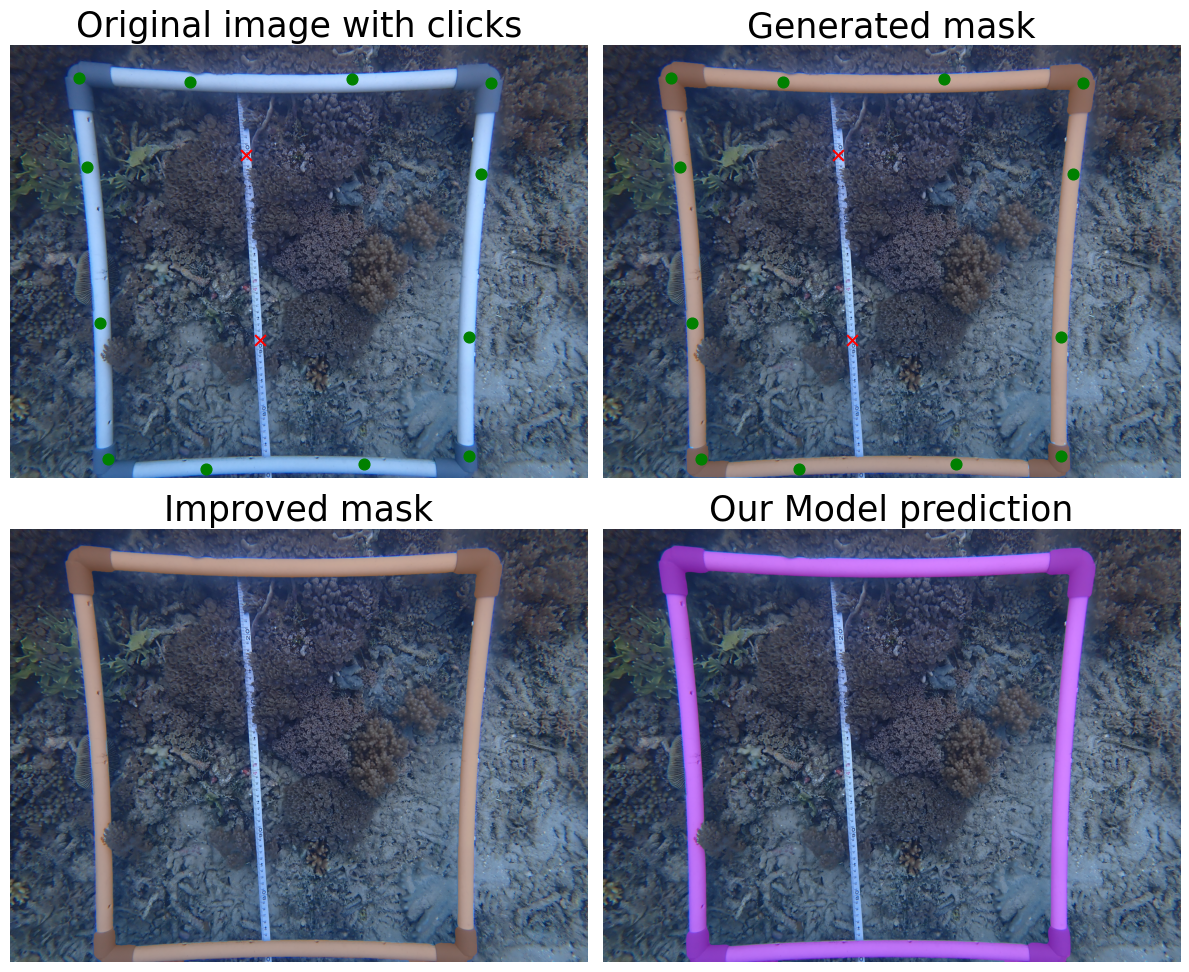

In [66]:
base = Path("./automated_underwater_area_estimation/data_preprocessed/IBF")
name = "GA 1_PB100683"
img_path = base / f"images/{name}.JPG"
clicks   = base / f"clicks/{name}_metadata.json"
gt_mask  = base / f"masks/{name}.pt"
imp_mask = base / f"improved_masks/{name}_improved.pt"
out_path = base / "viz_4panel.png"

output = visualize_four_panel(img_path, clicks, gt_mask, imp_mask, out_path)

# Side matching

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, Dict, Tuple
import torch
from PIL import Image
from pathlib import Path
from automated_underwater_area_estimation.area_estimation.quadrant_setup.area_estimation import (
    to_mask2d,
    find_four_points,
    compute_distances,
    pix_to_cm_square,
    median_band_average_from_cm_ratio,
)
plt.style.use('seaborn-v0_8-colorblind')

def visualize_cm_ratio_estimate(
    image_path: Union[str, Path],
    m_or_path: Union[str, torch.Tensor, np.ndarray],
    quadrant_width_cm: float,
    quadrant_height_cm: float,
    pct: float = 0.08,
    figsize: Tuple[float,float] = (10,10),
    base_fontsize: float = 18
) -> Tuple[float, float, float, Dict[str, float]]:
    """
    Visualize how the cm-ratio estimation works for a given mask, overlaying on the original image.

    Parameters:
      image_path: path to the original RGB image (so mask overlay makes sense)
      m_or_path: mask (tensor/ndarray/path) for the quadrant
      quadrant_width_cm, quadrant_height_cm: real-world size of the quadrant in cm
      pct: tolerance band fraction (e.g., 0.08 for ±8%)
      figsize: output figure size (width, height in inches)
      base_fontsize: base font size in points for major text elements (increase for large posters)

    Returns:
      (median, lo, hi, cm_sq_vals) where cm_sq_vals is dict mapping each distance‐key to its cm² estimate
    """
    # Load image
    img = Image.open(str(image_path)).convert("RGB")
    img_np = np.asarray(img)
    H, W = img_np.shape[:2]

    # Convert mask to 2D binary
    m = to_mask2d(m_or_path)
    if m.shape[0] != H or m.shape[1] != W:
        # if mask is different size than image → overlay only mask area; here we’ll just show mask on image by resizing mask
        from PIL import Image as PILImage
        pil_mask = PILImage.fromarray((m * 255).astype(np.uint8))
        pil_mask = pil_mask.resize((W, H), resample=PILImage.NEAREST)
        m = (np.asarray(pil_mask) > 127).astype(np.uint8)

    # Find corner points
    pts = find_four_points(m)

    # Compute pixel distances
    distances = compute_distances(m_or_path)

    # Compute cm² estimates
    cm_sq_vals = pix_to_cm_square(m_or_path, quadrant_width_cm, quadrant_height_cm)

    # Compute median + band
    vals = list(cm_sq_vals.values())
    s = sorted(vals)
    median = 0.5 * (s[2] + s[3])
    tol = pct * median
    lo, hi = median - tol, median + tol

    # Mark kept / rejected
    kept = {k:v for k,v in cm_sq_vals.items() if lo <= v <= hi}
    rejected = {k:v for k,v in cm_sq_vals.items() if not (lo <= v <= hi)}

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_np)

    # Draw mask overlay semi-transparent
    overlay = np.zeros_like(img_np, dtype=np.uint8)
    overlay[..., 0] = 255   # red channel highlight
    mask_bool = m.astype(bool)
    img_np2 = img_np.copy().astype(np.float32)
    img_np2[mask_bool] = img_np2[mask_bool] * (1 - 0.4) + overlay[mask_bool] * 0.4
    ax.imshow(img_np2.astype(np.uint8))

    # Plot points & annotate
    for name,(y,x) in pts.items():
        ax.scatter([x],[y], s=200, marker='o', edgecolors='k', facecolors='orange', linewidths=1.5)
        # ax.annotate(f"{name}\n({x},{y})",
        #             xy=(x,y),
        #             xytext=(x+20, y+20),
        #             fontsize=base_fontsize,
        #             color="white",
        #             arrowprops=dict(arrowstyle="->", lw=1.5))

    # Draw lines and annotate pixel & cm² conversions
    for k, pix_dist in distances.items():
        p1, p2 = k.split("_")
        y1,x1 = pts[p1]
        y2,x2 = pts[p2]
        ax.plot([x1,x2],[y1,y2], linestyle="--", color="white", linewidth=3)
        xm, ym = (x1+x2)/2, (y1+y2)/2
        v_cm2 = cm_sq_vals[k]
        # colour = "lime" if (lo <= v_cm2 <= hi) else "red"
        # ax.text(xm+10, ym+10,
        #         f"{k}\n{pix_dist:.1f}px → {v_cm2:.3f}cm²",
        #         fontsize=base_fontsize-2,
        #         color=colour,
        #         backgroundcolor="black",
        #         alpha=0.6)

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_aspect('equal')
    ax.set_xlabel("x (pixels)", fontsize=base_fontsize)
    ax.set_ylabel("y (pixels)", fontsize=base_fontsize)
    ax.tick_params(axis='both', labelsize=base_fontsize-2)
    ax.grid(True, linestyle=':', linewidth=0.8, alpha=0.5)

    plt.tight_layout()
    fig.savefig("quadrant.png", dpi=200, bbox_inches="tight")
    plt.show()

    return fig


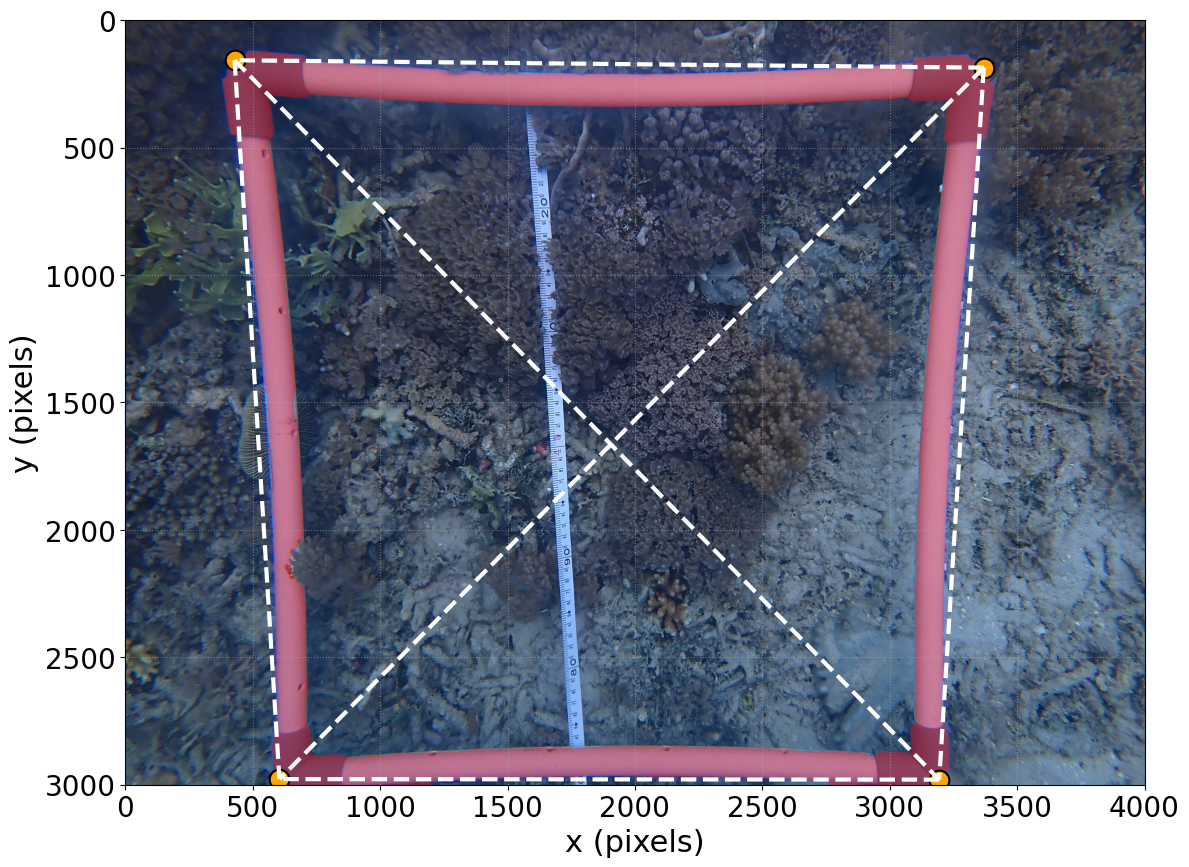

In [30]:
image_path = "./automated_underwater_area_estimation/data_preprocessed/IBF/images/GA 1_PB100683.JPG"
mask_path  = "./automated_underwater_area_estimation/data_preprocessed/IBF/improved_masks/GA 1_PB100683_improved.pt"
out = visualize_cm_ratio_estimate(
    image_path=image_path,
    m_or_path=mask_path,
    quadrant_width_cm=54,
    quadrant_height_cm=54,
    pct=0.08,
    figsize=(12,12),
    base_fontsize=22
)


# Images pipelines

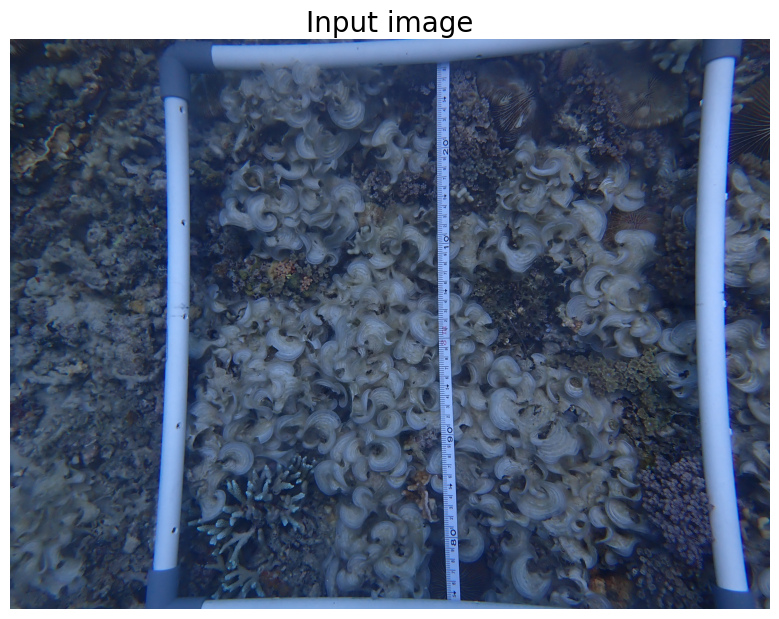

In [32]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from pathlib import Path

baseline = "GA 1_PB100637"
image_path = Path(f"./automated_underwater_area_estimation/data_preprocessed/IBF/images/{baseline}.JPG")
figsize = (8, 6)
titlefont = 20
alpha = 0.6

# Load image
img = Image.open(image_path).convert("RGB")
img_np = np.array(img)

# Plot
fig, ax = plt.subplots(figsize=figsize)
ax.imshow(img_np)
ax.set_title("Input image", fontsize=titlefont)
ax.axis('off')  # hide axes

# Remove margins:
ax.set_position([0, 0, 1, 1])     # Fill entire figure with the axes
plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

plt.tight_layout(pad=0)            # Remove padding
plt.margins(0, 0)                  # Remove data margins
plt.show()


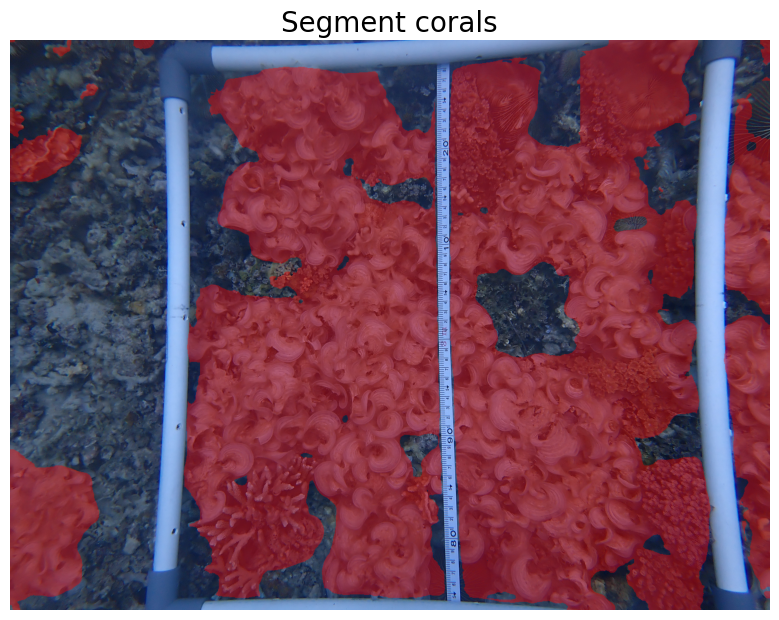

In [36]:
from automated_underwater_area_estimation.segmentation_corals.epfl.model import EPFLModel
coral_segmentation_model = EPFLModel("EPFL-ECEO/segformer-b5-finetuned-coralscapes-1024-1024")
img_prep, coral_segmentation_mask = coral_segmentation_model.segment_image(img, adjust_size=False, use_sliding_window=True)
mask = coral_segmentation_mask.cpu()
img_arr = np.array(img.convert("RGB"))

# Create an overlay image by blending: choose a colour for the mask (e.g., red) and alpha blending
overlay = img_arr.copy()
color = (255, 0, 0)
colour = np.array(color, dtype=np.uint8)     # red colour for segmentation

# Apply colour to overlay where mask is true
overlay[mask] = (overlay[mask] * (1 - alpha) + colour * alpha).astype(np.uint8)

# Plot it
plt.figure(figsize=figsize)
plt.imshow(overlay)
plt.title("Segment corals", fontsize=titlefont)   # you can increase fontsize if needed
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

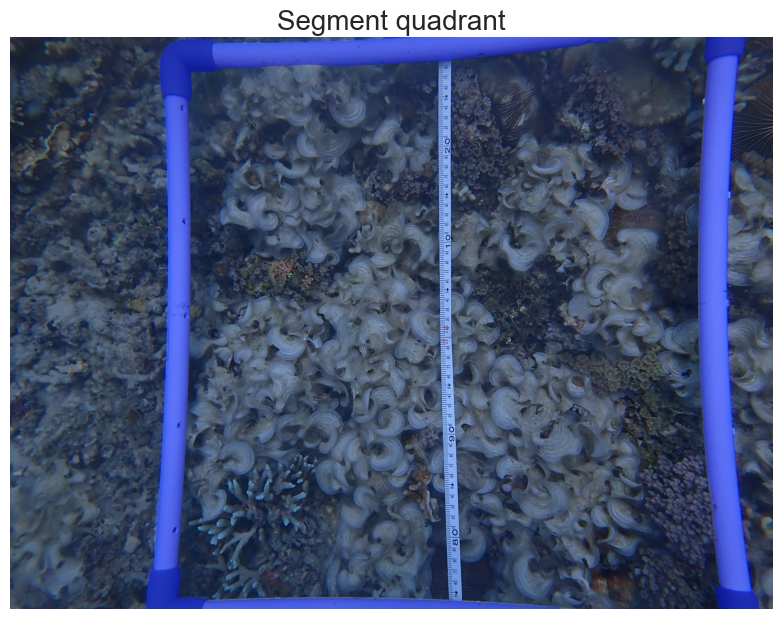

In [55]:
from automated_underwater_area_estimation.segmentation_quadrant.model import QuadrantSegmentationModel

quad_model = QuadrantSegmentationModel()
mask_quad = quad_model.segment_image(img)
mask_quad = mask_quad.astype(bool)
overlay_quad = img_arr.copy()
color = (0, 0, 255)
colour_blue = np.array(color, dtype=np.uint8)
overlay_quad[mask_quad] = (overlay_quad[mask_quad] * (1-alpha) + colour_blue * alpha).astype(np.uint8)

plt.figure(figsize=figsize)
plt.imshow(overlay_quad)
plt.title("Segment quadrant", fontsize=titlefont)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

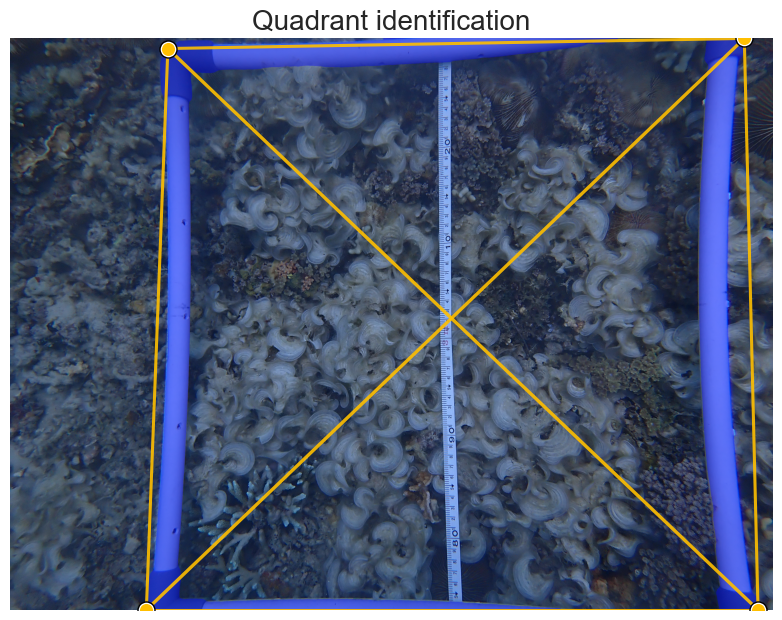

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, Dict, Tuple

def to_mask2d(m_or_path: Union[str, np.ndarray]) -> np.ndarray:
    m = np.asarray(m_or_path)
    m = (np.squeeze(m) > 0).astype(np.uint8)
    if m.ndim != 2:
        raise ValueError(f"Expected 2D mask, got shape {m.shape}")
    return m

def point_bottom_right(m: np.ndarray) -> Tuple[int, int]:
    ys, xs = np.where(m == 1)
    if ys.size == 0: raise ValueError("Mask is empty.")
    i = (ys.astype(np.int64) * xs.astype(np.int64)).argmax()
    return int(ys[i]), int(xs[i])

def point_top_left(m: np.ndarray) -> Tuple[int, int]:
    ys, xs = np.where(m == 1)
    keep = (ys > 0) & (xs > 0)
    ys, xs = ys[keep], xs[keep]
    if ys.size == 0: raise ValueError("No white pixels with x>0 and y>0.")
    sums = ys.astype(np.int64) + xs.astype(np.int64)
    min_sum = sums.min()
    idx = np.where(sums == min_sum)[0]
    y_sel = int(ys[idx].min())
    x_sel = int(xs[idx][ys[idx] == y_sel].min())
    return y_sel, x_sel

def point_top_right(m: np.ndarray) -> Tuple[int, int]:
    ys, xs = np.where(m == 1)
    diffs = xs.astype(np.int64) - ys.astype(np.int64)
    best = diffs.max()
    keep = (diffs == best)
    xs_t, ys_t = xs[keep], ys[keep]
    x_sel = int(xs_t.max())
    y_sel = int(ys_t[xs_t == x_sel].min())
    return y_sel, x_sel

def point_bottom_left(m: np.ndarray) -> Tuple[int, int]:
    ys, xs = np.where(m == 1)
    diffs = ys.astype(np.int64) - xs.astype(np.int64)
    best = diffs.max()
    keep = (diffs == best)
    ys_t, xs_t = ys[keep], xs[keep]
    y_sel = int(ys_t.max())
    x_sel = int(xs_t[ys_t == y_sel].min())
    return y_sel, x_sel

def find_four_points(mask_2d: Union[str, np.ndarray]) -> Dict[str, Tuple[int,int]]:
    m = to_mask2d(mask_2d)
    return {
        "TL": point_top_left(m),
        "TR": point_top_right(m),
        "BR": point_bottom_right(m),
        "BL": point_bottom_left(m),
    }

pt_color = {"TL": "#FFBF00", "TR": "#FFBF00", "BR": "#FFBF00", "BL": "#FFBF00"}
side_color = "#FFBF00"
diag_colors = {"TL_BR": "#FFBF00", "TR_BL": "#FFBF00"}

pts = find_four_points(mask_quad)

fig, ax = plt.subplots(figsize=figsize)
ax.imshow(overlay_quad)  # overlay from your code above

# plot corner points + labels
for k, (y, x) in pts.items():
    ax.scatter([x], [y], s=150, facecolor="white", edgecolor="black", zorder=4)
    ax.scatter([x], [y], s=70, color=pt_color[k], zorder=5)

# draw sides and diagonals
sides = [("TR", "TL"), ("TR", "BR"), ("BL", "BR"), ("TL", "BL")]
diags = [("TL", "BR"), ("TR", "BL")]

def draw_seg(a, b, color, lw=2.4, z=2):
    (y1, x1), (y2, x2) = pts[a], pts[b]
    ax.plot([x1, x2], [y1, y2], color=color, lw=lw, alpha=0.9, zorder=z)

for a, b in sides:
    draw_seg(a, b, side_color, lw=2.2, z=2)
for (a, b), key in zip(diags, ["TL_BR", "TR_BL"]):
    draw_seg(a, b, diag_colors[key], lw=2.4, z=1)

ax.set_title("Quadrant identification", fontsize=titlefont)
ax.set_axis_off()
plt.tight_layout(pad=0)
plt.show()